In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from keras import Input
from keras.layers import Dense, Reshape, LeakyReLU, Conv2D, Conv2DTranspose, Flatten, Dropout
from keras.models import Model
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import load_img
from keras.optimizers import Adam

c:\Users\hartono\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\hartono\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\hartono\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violation

In [ ]:
dir =  r"C:/Users/hartono/OneDrive/ドキュメント/BINUS/Projects & Lomba/CeleBA Image Generator/img_align_celeba"

count_images = 2000

ori_height =  218 # Koreksi dari 208 ke 218, ukuran asli CelebA
ori_width = 178
dif = (ori_height - ori_width) // 2

width = 128
height = 128

# img_crop sedikit disesuaikan untuk centering yang lebih baik
img_crop = (0, dif, ori_width, ori_height - dif)

images = []
for ori_pic in tqdm(os.listdir(dir)[:count_images]):
    path = os.path.join(dir, ori_pic)
    pic = Image.open(path).crop(img_crop)
    pic = pic.resize((width, height), Image.LANCZOS) 
    images.append(np.array(pic))
    
images = np.array(images)

# Normalisasi gambar ke rentang [-1, 1] agar sesuai dengan output 'tanh' dari generator
images = (images.astype('float32') - 127.5) / 127.5

print(images.shape)

100%|██████████| 2000/2000 [00:02<00:00, 807.13it/s]


(2000, 128, 128, 3)


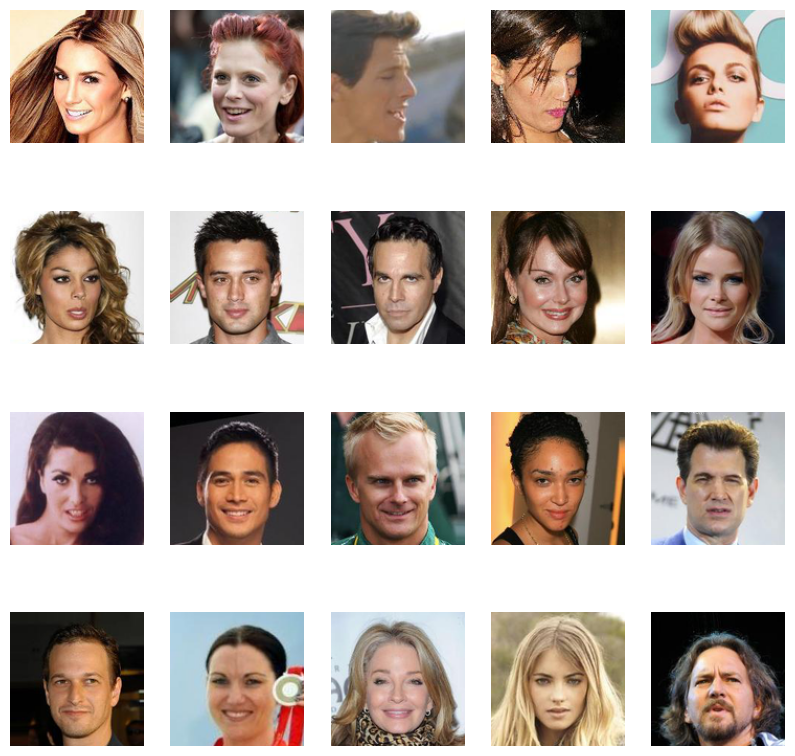

In [ ]:
plt.figure(1, figsize=(10, 10))
for i in range(20):
    # Denormalisasi gambar untuk ditampilkan dengan benar
    plt.subplot(4, 5, i+1)
    img_display = (images[i] * 127.5 + 127.5).astype('uint8')
    plt.imshow(img_display)
    plt.axis('off')
plt.show()

In [ ]:
dimension = 100 # Dimensi noise/laten standar
color = 3

def create_generator():
    gen_input = Input(shape=(dimension, ))

    x = Dense(128 * 16 * 16)(gen_input)
    x = LeakyReLU(alpha=0.2)(x) # Menambahkan alpha
    x = Reshape((16, 16, 128))(x)

    x = Conv2D(256, 5, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2DTranspose(256, 4, strides=2, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2DTranspose(256, 4, strides=2, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2DTranspose(256, 4, strides=2, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2D(512, 5, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Conv2D(512, 5, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    
    # Aktivasi 'tanh' menghasilkan nilai antara -1 dan 1
    x = Conv2D(color, 7, activation='tanh', padding='same')(x)

    generator = Model(gen_input, x)
    return generator

In [ ]:
def create_discriminator():
    disc_input = Input(shape=(height, width, color))

    x = Conv2D(128, 3)(disc_input) # Mengurangi filter awal
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2D(128, 4, strides=2)(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2D(256, 4, strides=2)(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2D(256, 4, strides=2)(x)
    x = LeakyReLU(alpha=0.2)(x)
    
    x = Conv2D(256, 4, strides=2)(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Flatten()(x)
    x = Dropout(0.4)(x)

    x = Dense(1, activation='sigmoid')(x)
    discriminator = Model(disc_input, x)

    # Menggunakan Adam Optimizer, yang umum untuk GANs
    optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

    discriminator.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return discriminator

In [ ]:
generator = create_generator()
discriminator = create_discriminator()

# Membuat discriminator tidak dapat dilatih saat melatih generator
discriminator.trainable = False

gan_input = Input(shape=(dimension, ))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output)

optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
gan.compile(optimizer=optimizer, loss='binary_crossentropy')

gan.summary()

c:\Users\hartono\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 128, 128, 3)    │    17,182,211 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 1)              │     2,897,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,079,492 (76.60 MB)

 Trainable params: 17,182,211 (65.54 MB)

 Non-trainable params: 2,897,281 (11.05 MB)

In [ ]:
epochs = 50 # Menambah epoch untuk hasil lebih baik
batch_size = 32

d_losses = []
g_losses = []

# Membuat noise yang tetap untuk visualisasi agar bisa melihat progres
seed = np.random.normal(0, 1, size=[batch_size, dimension])

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    
    # Menggunakan tqdm untuk progress bar yang lebih informatif
    for i in tqdm(range(images.shape[0] // batch_size)):
        # 1. Melatih Discriminator
        
        # Gambar asli dari dataset
        real_images = images[i*batch_size : (i+1)*batch_size]
        real_labels = np.ones((batch_size, 1))
        
        # Gambar palsu yang di-generate
        noise = np.random.normal(0, 1, size=[batch_size, dimension])
        fake_images = generator.predict(noise)
        fake_labels = np.zeros((batch_size, 1))
        
        # Menggabungkan gambar asli dan palsu untuk dilatih bersamaan
        x_combined = np.concatenate([real_images, fake_images])
        y_combined = np.concatenate([real_labels, fake_labels])
        
        # Melatih discriminator
        discriminator.trainable = True
        d_loss = discriminator.train_on_batch(x_combined, y_combined)
        
        # 2. Melatih Generator
        noise = np.random.normal(0, 1, size=[batch_size, dimension])
        y_mislabeled = np.ones((batch_size, 1))
        
        # Mengunci (freeze) discriminator dan melatih generator
        discriminator.trainable = False
        g_loss = gan.train_on_batch(noise, y_mislabeled)
        
    # Menyimpan loss untuk di-plot nanti
    d_losses.append(d_loss[0])
    g_losses.append(g_loss)
    
    print(f"  Discriminator Loss: {d_loss[0]:.4f}, Accuracy: {d_loss[1]:.2f} | Generator Loss: {g_loss:.4f}")
    
    # Menampilkan hasil generate setiap beberapa epoch
    if (epoch + 1) % 5 == 0:
        generated_images = generator.predict(seed)
        generated_images = 0.5 * generated_images + 0.5 # Rescale ke [0, 1] untuk ditampilkan
        
        plt.figure(figsize=(10, 10))
        for j in range(16): # Menampilkan 16 gambar
            plt.subplot(4, 4, j+1)
            plt.imshow(generated_images[j])
            plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Menyimpan model setiap 5 epoch
        generator.save_weights(f'generator_epoch_{epoch+1}.weights.h5')

print('Pelatihan Selesai')

Epoch 1/50


  0%|          | 0/62 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


  2%|▏         | 1/62 [01:14<1:15:38, 74.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 46s 46s/step


 56%|█████▋    | 35/62 [57:00<1:13:33, 163.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 45s 45s/step


 58%|█████▊    | 36/62 [59:46<1:11:07, 164.14s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 45s 45s/step
